# **Importing all Neccessary Modules**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
DATASET_PATH = "/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv"

df = pd.read_csv(DATASET_PATH)
df.drop(columns=['Id'], inplace=True)
df['Species'] = df['Species'].str.replace("Iris-", "", case=False).str.strip().str.capitalize()

FEATURE_COLS = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
TARGET_COL   = 'Species'

print(df.head())
print(f"\nShape      : {df.shape}")
print(f"Classes    : {df[TARGET_COL].unique()}")
print(f"\nClass Distribution:\n{df[TARGET_COL].value_counts()}")

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  Setosa
1            4.9           3.0            1.4           0.2  Setosa
2            4.7           3.2            1.3           0.2  Setosa
3            4.6           3.1            1.5           0.2  Setosa
4            5.0           3.6            1.4           0.2  Setosa

Shape      : (150, 5)
Classes    : ['Setosa' 'Versicolor' 'Virginica']

Class Distribution:
Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


# **Data Quality Check**

In [3]:
print(f"Null Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nData Types:\n{df.dtypes}")

df.drop_duplicates(inplace=True)

le       = LabelEncoder()
df['label'] = le.fit_transform(df[TARGET_COL])

X = df[FEATURE_COLS]
y = df['label']

print(f"\nTotal samples after preprocessing: {len(df)}")

Null Values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate Rows: 3

Data Types:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Total samples after preprocessing: 147


# **Exploratory Data Analysis**

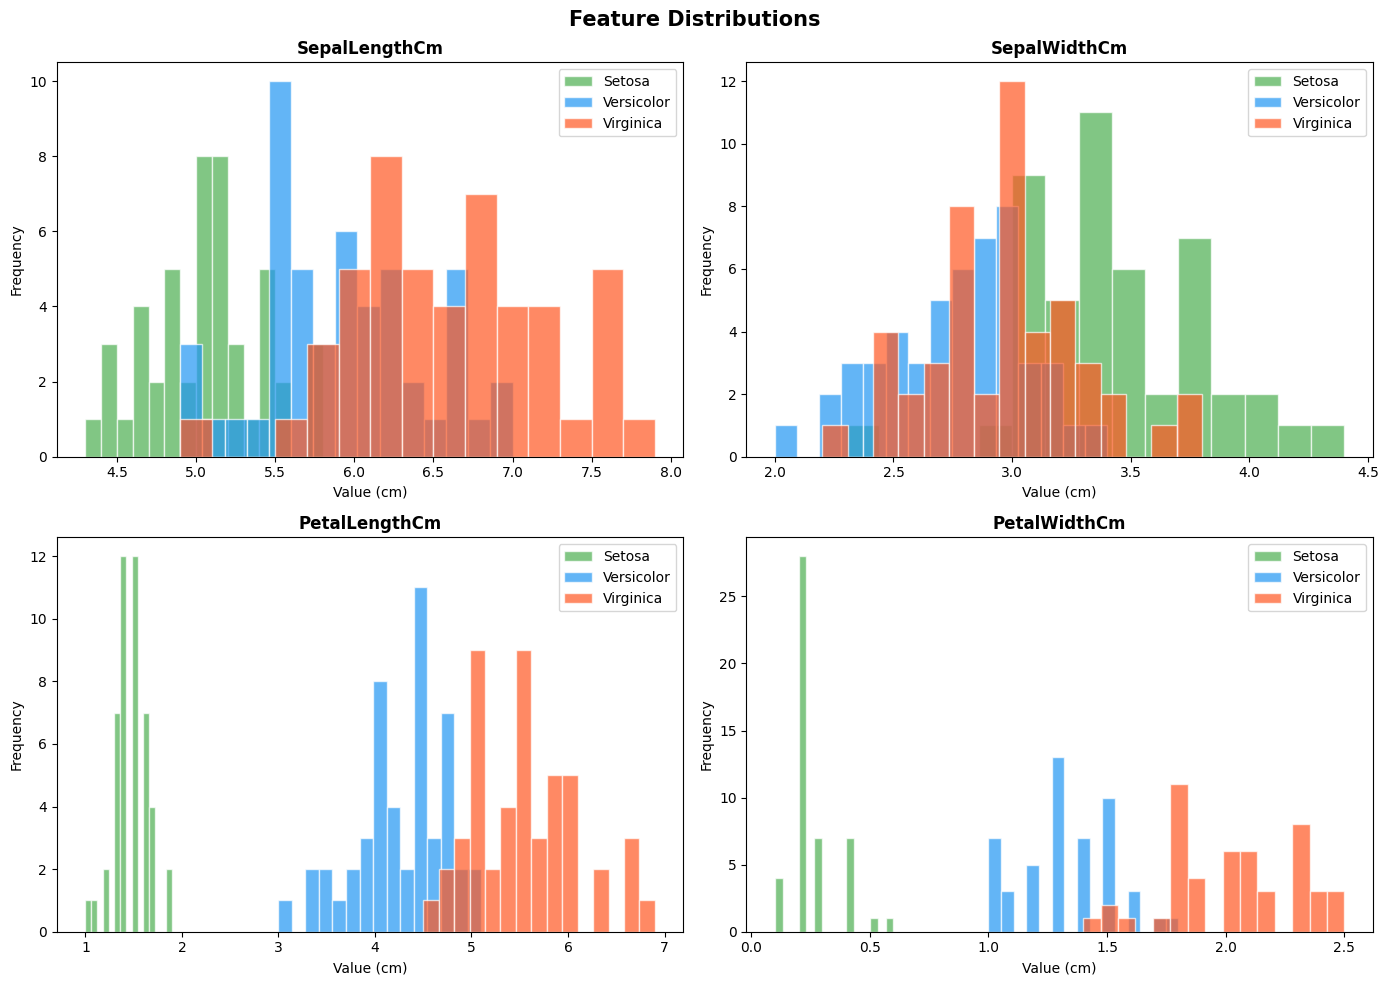

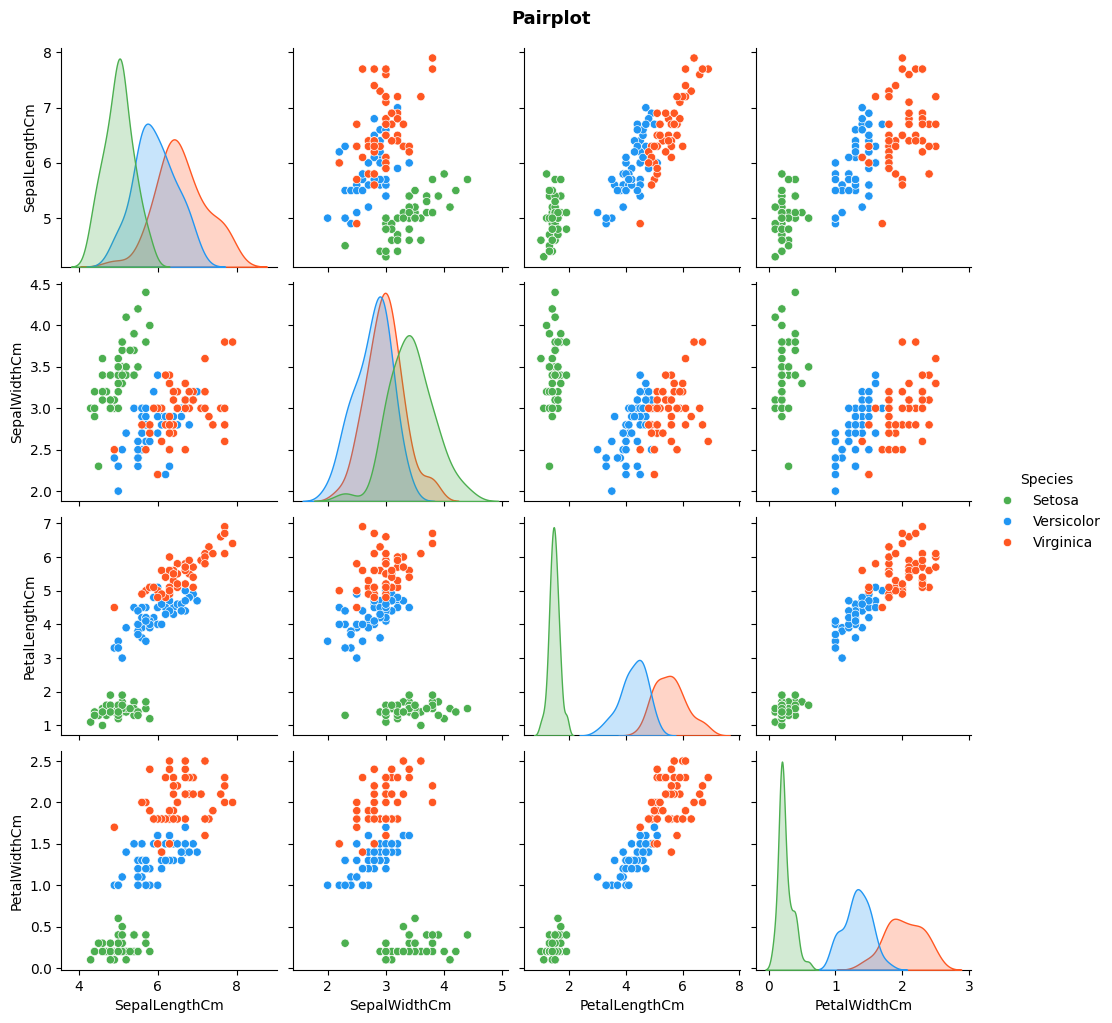

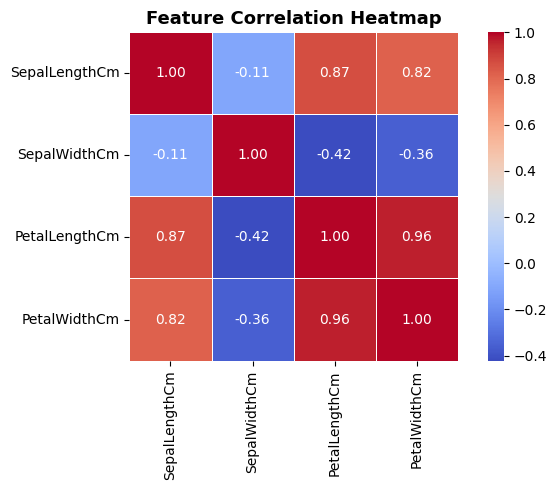

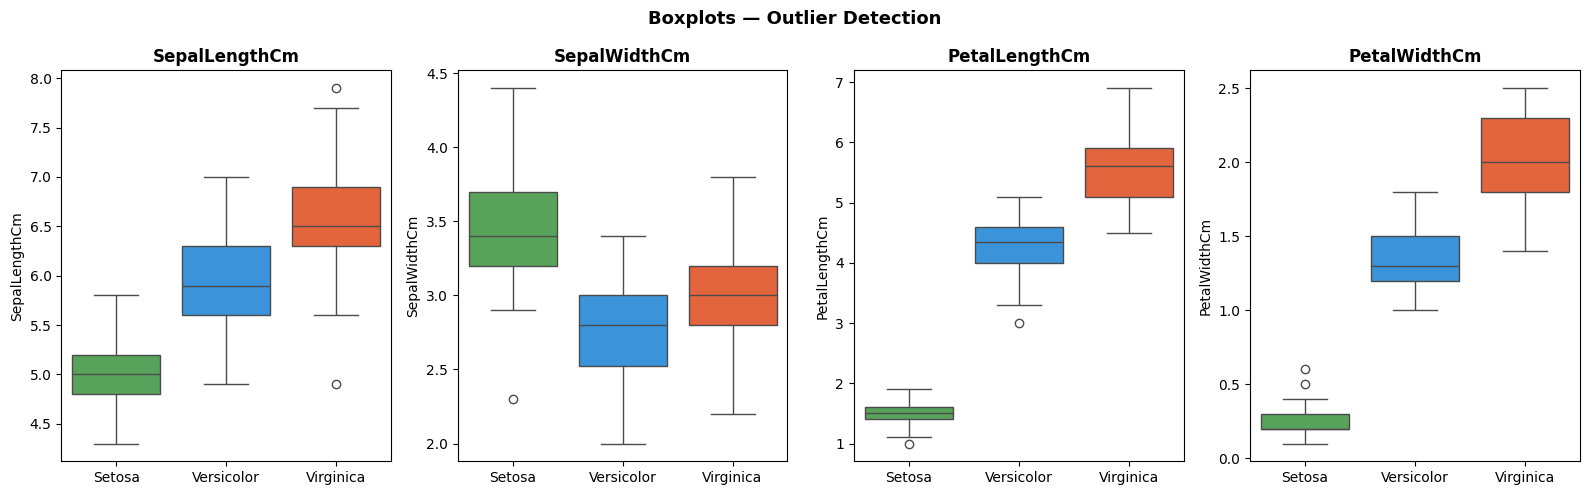

In [4]:
PALETTE = {'Setosa': '#4CAF50', 'Versicolor': '#2196F3', 'Virginica': '#FF5722'}

# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions", fontsize=15, fontweight='bold')
for idx, feature in enumerate(FEATURE_COLS):
    ax = axes[idx // 2][idx % 2]
    for cls, color in PALETTE.items():
        ax.hist(df[df[TARGET_COL] == cls][feature], alpha=0.7,
                label=cls, color=color, bins=15, edgecolor='white')
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel("Value (cm)")
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# Pairplot
pair = sns.pairplot(df[FEATURE_COLS + [TARGET_COL]], hue=TARGET_COL,
                    palette=PALETTE, diag_kind='kde')
pair.fig.suptitle("Pairplot", y=1.02, fontsize=13, fontweight='bold')
plt.savefig("pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[FEATURE_COLS].corr(), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Boxplots — Outlier Detection", fontsize=13, fontweight='bold')
for idx, feature in enumerate(FEATURE_COLS):
    sns.boxplot(data=df, x=TARGET_COL, y=feature, palette=PALETTE, ax=axes[idx])
    axes[idx].set_title(feature, fontweight='bold')
    axes[idx].set_xlabel("")
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

# **Train & Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")

Train size : 117 samples
Test size  : 30 samples


# **Tuning Hyperparameters**

In [6]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100, 200], 'max_depth': [None, 3, 5, 10]},
    cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
print(f"Random Forest — Best Params: {rf_grid.best_params_}")

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly']},
    cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print(f"SVM           — Best Params: {svm_grid.best_params_}")

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9, 11]},
    cv=5, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
print(f"KNN           — Best Params: {knn_grid.best_params_}")

Random Forest — Best Params: {'max_depth': 3, 'n_estimators': 100}
SVM           — Best Params: {'C': 0.1, 'kernel': 'linear'}
KNN           — Best Params: {'n_neighbors': 3}


# **Soft Voting**

In [7]:
# HYBRID VOTING CLASSIFIER 

voting_clf = VotingClassifier(
    estimators=[('RandomForest', best_rf), ('SVM', best_svm), ('KNN', best_knn)],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
print("Hybrid Voting Classifier trained successfully.")

Hybrid Voting Classifier trained successfully.


# **Model Evaluation**

In [8]:
models  = {
    'Random Forest':      best_rf,
    'SVM':                best_svm,
    'KNN':                best_knn,
    'Hybrid Voting Model': voting_clf
}
results = {}

for name, model in models.items():
    y_pred    = model.predict(X_test_scaled)
    acc       = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'accuracy': acc,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'y_pred':   y_pred
    }
    print(f"\n{'─'*45}")
    print(f"  Model    : {name}")
    print(f"  Accuracy : {acc * 100:.2f}%")
    print(f"  CV Score : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


─────────────────────────────────────────────
  Model    : Random Forest
  Accuracy : 96.67%
  CV Score : 95.69% +/- 4.76%

  Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


─────────────────────────────────────────────
  Model    : SVM
  Accuracy : 93.33%
  CV Score : 97.43% +/- 3.46%

  Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
w

# **Model Performance Comparison**

In [9]:
comparison_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [f"{v['accuracy']*100:.2f}%" for v in results.values()],
    'CV Mean':  [f"{v['cv_mean']*100:.2f}%"  for v in results.values()],
    'CV Std':   [f"+/-{v['cv_std']*100:.2f}%" for v in results.values()]
})
print(comparison_df.to_string(index=False))

              Model Accuracy CV Mean   CV Std
      Random Forest   96.67%  95.69% +/-4.76%
                SVM   93.33%  97.43% +/-3.46%
                KNN   93.33%  94.89% +/-5.03%
Hybrid Voting Model   90.00%  95.72% +/-2.75%


# **Plottings**

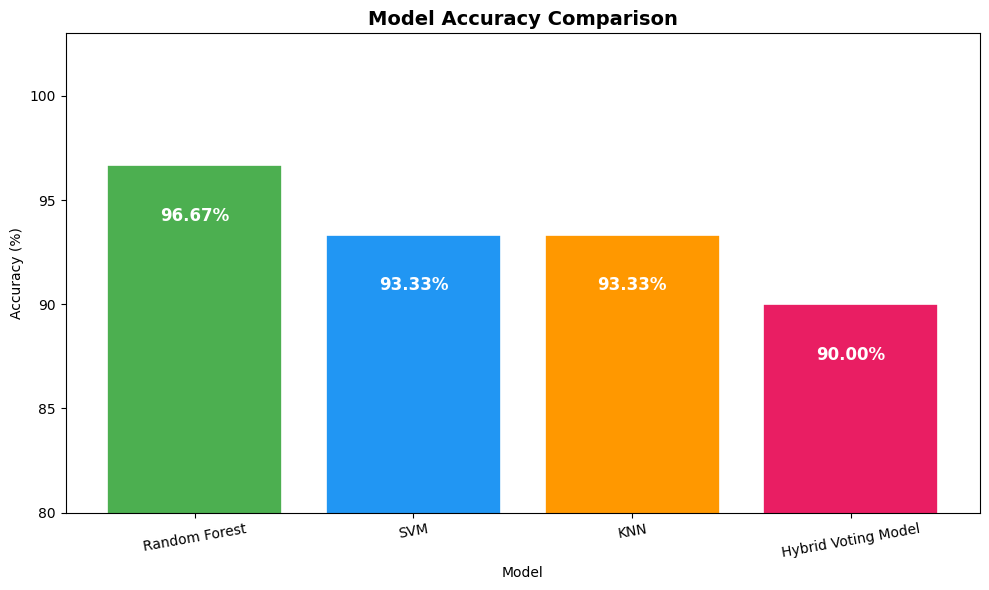

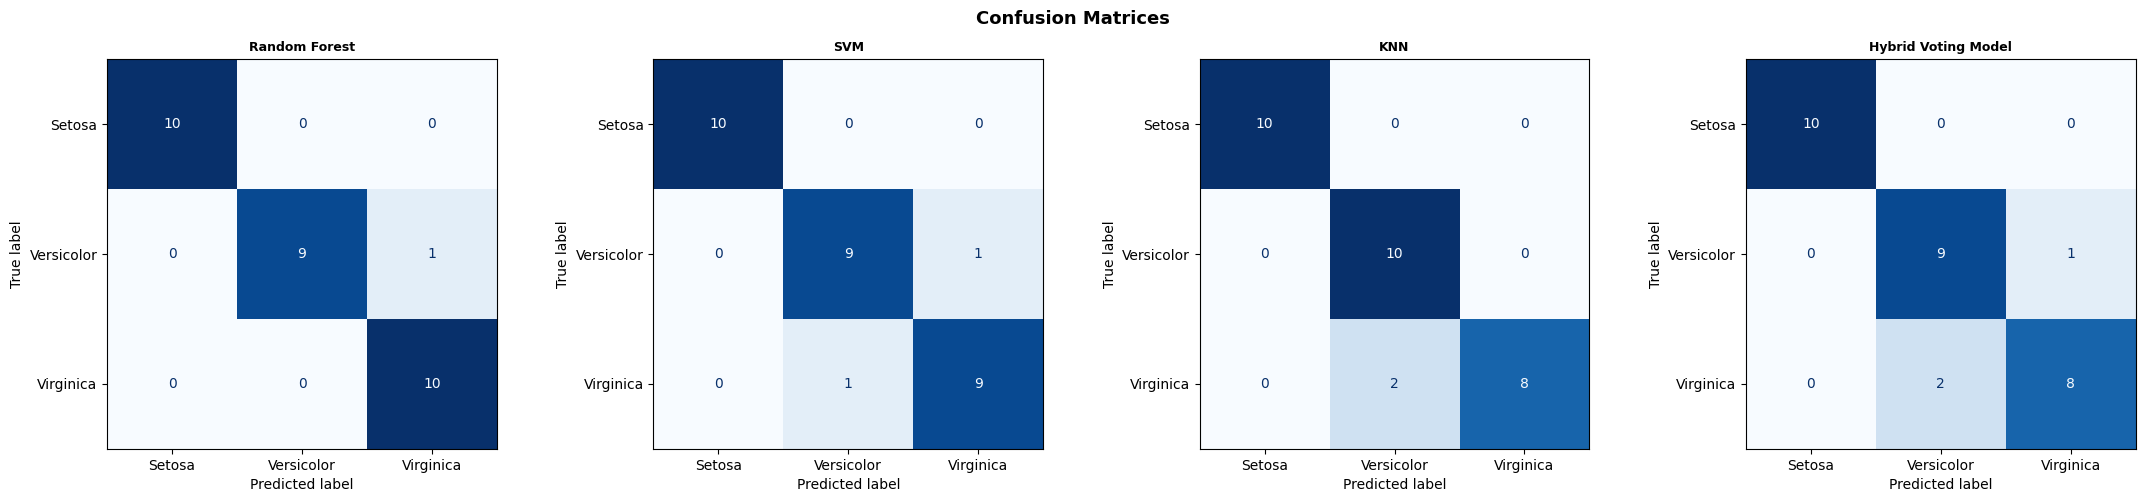

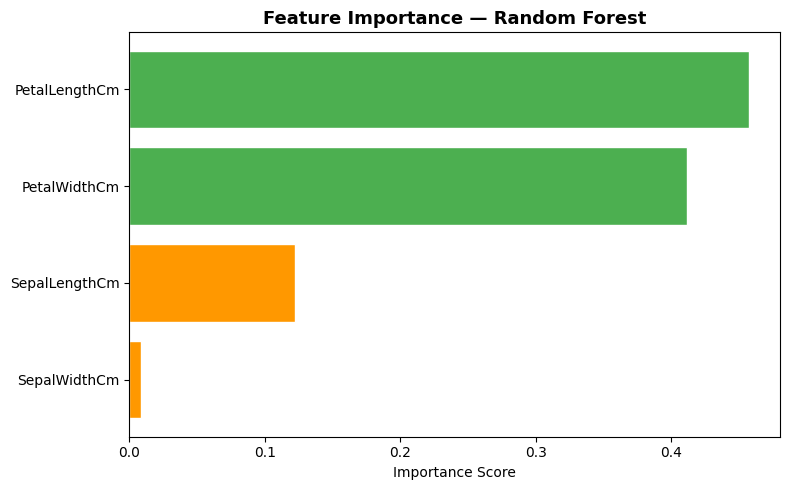

In [10]:
# Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
names  = list(results.keys())
accs   = [v['accuracy'] * 100 for v in results.values()]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']
bars   = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.2)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
             f"{acc:.2f}%", ha='center', va='top',
             fontsize=12, fontweight='bold', color='white')
plt.ylim(80, 103)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight='bold')
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance — Random Forest
plt.figure(figsize=(8, 5))
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': best_rf.feature_importances_})
feat_df.sort_values('Importance', ascending=True, inplace=True)
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=['#FF9800', '#FF9800', '#4CAF50', '#4CAF50'], edgecolor='white')
plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# **Sample Prediction Test**

In [11]:
# [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
test_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],   # Setosa
    [6.3, 3.3, 4.7, 1.6],   # Versicolor
    [6.9, 3.1, 5.4, 2.1],   # Virginica
    [4.8, 3.0, 1.4, 0.1],   # Setosa
    [5.9, 2.7, 4.2, 1.3],   # Versicolor
    [7.2, 3.6, 6.1, 2.5],   # Virginica
])
actual_labels = ['Setosa', 'Versicolor', 'Virginica', 'Setosa', 'Versicolor', 'Virginica']

test_samples_scaled = scaler.transform(test_samples)

print(f"{'Sample':<10} {'Actual':<15} {'Random Forest':<18} {'SVM':<18} {'KNN':<18} {'Hybrid Voting':<18}")
print("-" * 97)

sample_results = {name: [] for name in models}

for i, (sample, actual) in enumerate(zip(test_samples_scaled, actual_labels)):
    row = f"  {i+1:<8} {actual:<15}"
    for name, model in models.items():
        pred = le.inverse_transform(model.predict([sample]))[0]
        sample_results[name].append(pred == actual)
        match = "Correct" if pred == actual else "Wrong"
        row += f" {pred} ({match})".ljust(18)
    print(row)

print("\nPer-Model Accuracy on Test Samples:")
print("-" * 40)
for name, correct_list in sample_results.items():
    acc = sum(correct_list) / len(correct_list) * 100
    print(f"  {name:<25} : {acc:.1f}%  ({sum(correct_list)}/{len(correct_list)} correct)")

Sample     Actual          Random Forest      SVM                KNN                Hybrid Voting     
-------------------------------------------------------------------------------------------------
  1        Setosa          Setosa (Correct)  Setosa (Correct)  Setosa (Correct)  Setosa (Correct) 
  2        Versicolor      Versicolor (Correct) Versicolor (Correct) Versicolor (Correct) Versicolor (Correct)
  3        Virginica       Virginica (Correct) Virginica (Correct) Virginica (Correct) Virginica (Correct)
  4        Setosa          Setosa (Correct)  Setosa (Correct)  Setosa (Correct)  Setosa (Correct) 
  5        Versicolor      Versicolor (Correct) Versicolor (Correct) Versicolor (Correct) Versicolor (Correct)
  6        Virginica       Virginica (Correct) Virginica (Correct) Virginica (Correct) Virginica (Correct)

Per-Model Accuracy on Test Samples:
----------------------------------------
  Random Forest             : 100.0%  (6/6 correct)
  SVM                       : 100.0

# **Saving Models**

In [12]:
joblib.dump(best_rf,    "model_random_forest.joblib")
joblib.dump(best_svm,   "model_svm.joblib")
joblib.dump(best_knn,   "model_knn.joblib")
joblib.dump(voting_clf, "model_hybrid_voting.joblib")
joblib.dump(scaler,     "scaler.joblib")
joblib.dump(le,         "label_encoder.joblib")

with open("model_random_forest.pkl", "wb") as f: pickle.dump(best_rf,    f)
with open("model_svm.pkl",           "wb") as f: pickle.dump(best_svm,   f)
with open("model_knn.pkl",           "wb") as f: pickle.dump(best_knn,   f)
with open("model_hybrid_voting.pkl", "wb") as f: pickle.dump(voting_clf, f)
with open("scaler.pkl",              "wb") as f: pickle.dump(scaler,     f)
with open("label_encoder.pkl",       "wb") as f: pickle.dump(le,         f)

print("All models saved successfully (joblib + pickle).")

All models saved successfully (joblib + pickle).


# **Load & Verify Saved Model**

In [13]:
loaded_model  = joblib.load("model_hybrid_voting.joblib")
loaded_scaler = joblib.load("scaler.joblib")
loaded_le     = joblib.load("label_encoder.joblib")

sample        = np.array([[5.1, 3.5, 1.4, 0.2]])
sample_scaled = loaded_scaler.transform(sample)
pred_label    = loaded_model.predict(sample_scaled)[0]

print(f"Sample Input     : {sample[0]}")
print(f"Predicted Species: {loaded_le.inverse_transform([pred_label])[0]}")
print("Model loaded and verified successfully.")

Sample Input     : [5.1 3.5 1.4 0.2]
Predicted Species: Setosa
Model loaded and verified successfully.
